In [1]:
import os
import tensorflow as tf
import pandas as pd
import sys
import matplotlib.pyplot as plt
from itertools import permutations, combinations
from matplotlib import rcParams, cycler
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc7 import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01, 0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [4]:
perm_combos = np.array(list(combinations((combinations(permutations(np.arange(3)), 2)), 7)))

In [5]:
# Make the permutation matrices
perm_combos = np.array(list(combinations((combinations(permutations(np.arange(3)), 2)), 7)))#.transpose(0,2,3,1)

perm_combos = tf.one_hot(
    perm_combos,
    3,
    axis=-1,
)
perm_combos = tf.transpose(perm_combos, (0,1,2,4,3))

perm_combos = tf.where(perm_combos == 1.0, 
                  tf.ones_like(perm_combos) * 10.0,   # large positive
                  tf.ones_like(perm_combos) * -10.0)  # large negative

In [6]:
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

In [7]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [8]:
model = SGCCircuit(bounds = param_bounds, enforce_permutation=perm_combos[:10])
model.initialize_random_parameters(2,3,10)
optimizer1 = Optimize(model, epochs=100)
optimizer1.fit(X, Y_true)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x000002A45E9D2A90>
Training step = 0, N_exploration_samples = 10,
min_loss = 1.7472918033599854
med_loss = 9.085679054260254
max_loss = 31.472965240478516



<tf.Tensor: shape=(100, 10), dtype=float16, numpy=
array([[ 8.086 ,  3.205 ,  9.71  , 16.38  ,  1.747 ,  8.46  , 31.47  ,
         7.133 , 11.55  , 21.1   ],
       [ 8.06  ,  3.197 ,  9.68  , 16.34  ,  1.739 ,  8.43  , 31.4   ,
         7.113 , 11.51  , 21.03  ],
       [ 8.04  ,  3.188 ,  9.64  , 16.3   ,  1.732 ,  8.41  , 31.33  ,
         7.09  , 11.48  , 20.98  ],
       [ 8.02  ,  3.18  ,  9.61  , 16.25  ,  1.725 ,  8.375 , 31.27  ,
         7.07  , 11.44  , 20.92  ],
       [ 8.    ,  3.172 ,  9.58  , 16.22  ,  1.718 ,  8.35  , 31.19  ,
         7.047 , 11.41  , 20.86  ],
       [ 7.98  ,  3.162 ,  9.54  , 16.17  ,  1.71  ,  8.32  , 31.12  ,
         7.023 , 11.37  , 20.8   ],
       [ 7.96  ,  3.154 ,  9.51  , 16.12  ,  1.702 ,  8.3   , 31.05  ,
         7.004 , 11.33  , 20.73  ],
       [ 7.94  ,  3.146 ,  9.48  , 16.08  ,  1.695 ,  8.27  , 30.98  ,
         6.98  , 11.3   , 20.69  ],
       [ 7.92  ,  3.137 ,  9.44  , 16.05  ,  1.6875,  8.24  , 30.9   ,
         6.96  , 11.26

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

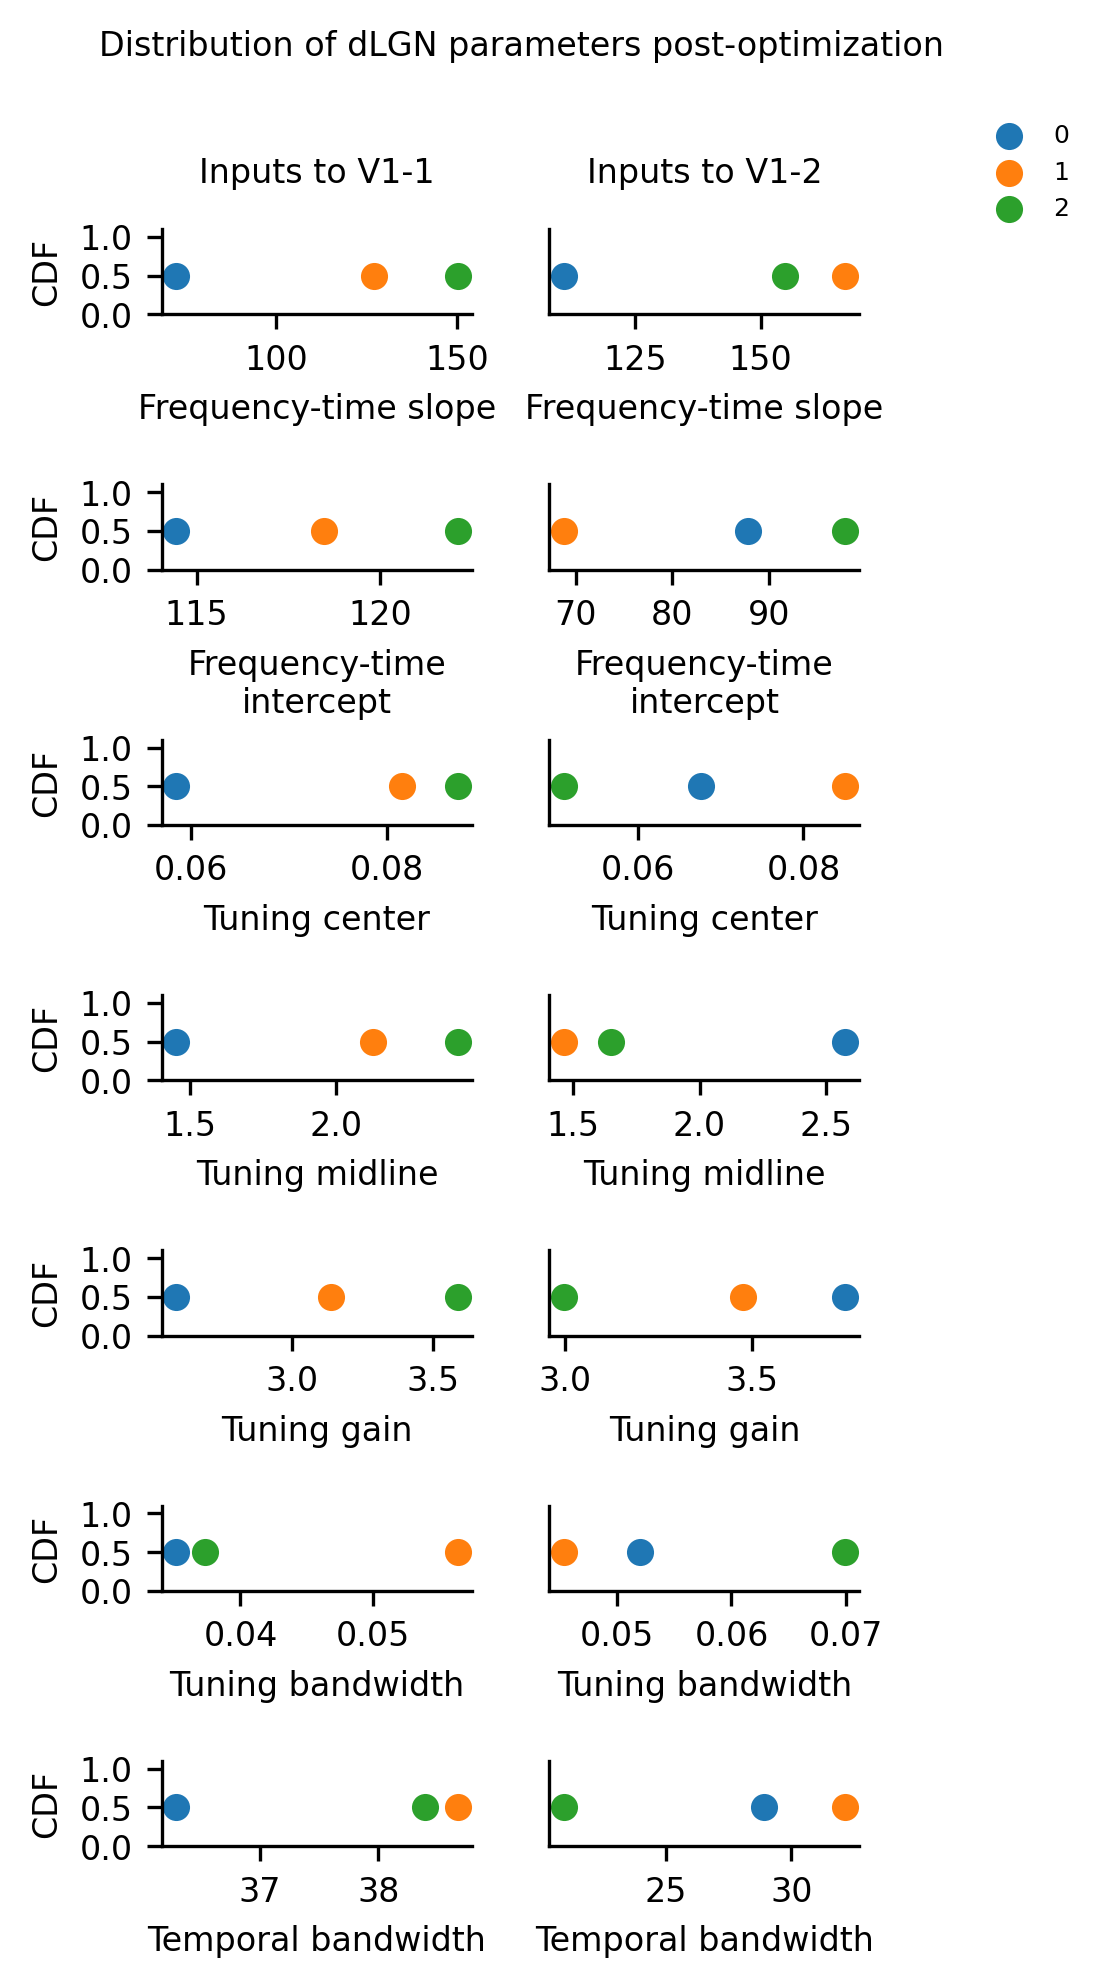

In [9]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(model.params['dLGN_params'][0, u, i, row, 0, 0], [0.5], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)


In [10]:
perm_combos = np.array(list(combinations((combinations(permutations(np.arange(3)), 2)), 7)))

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

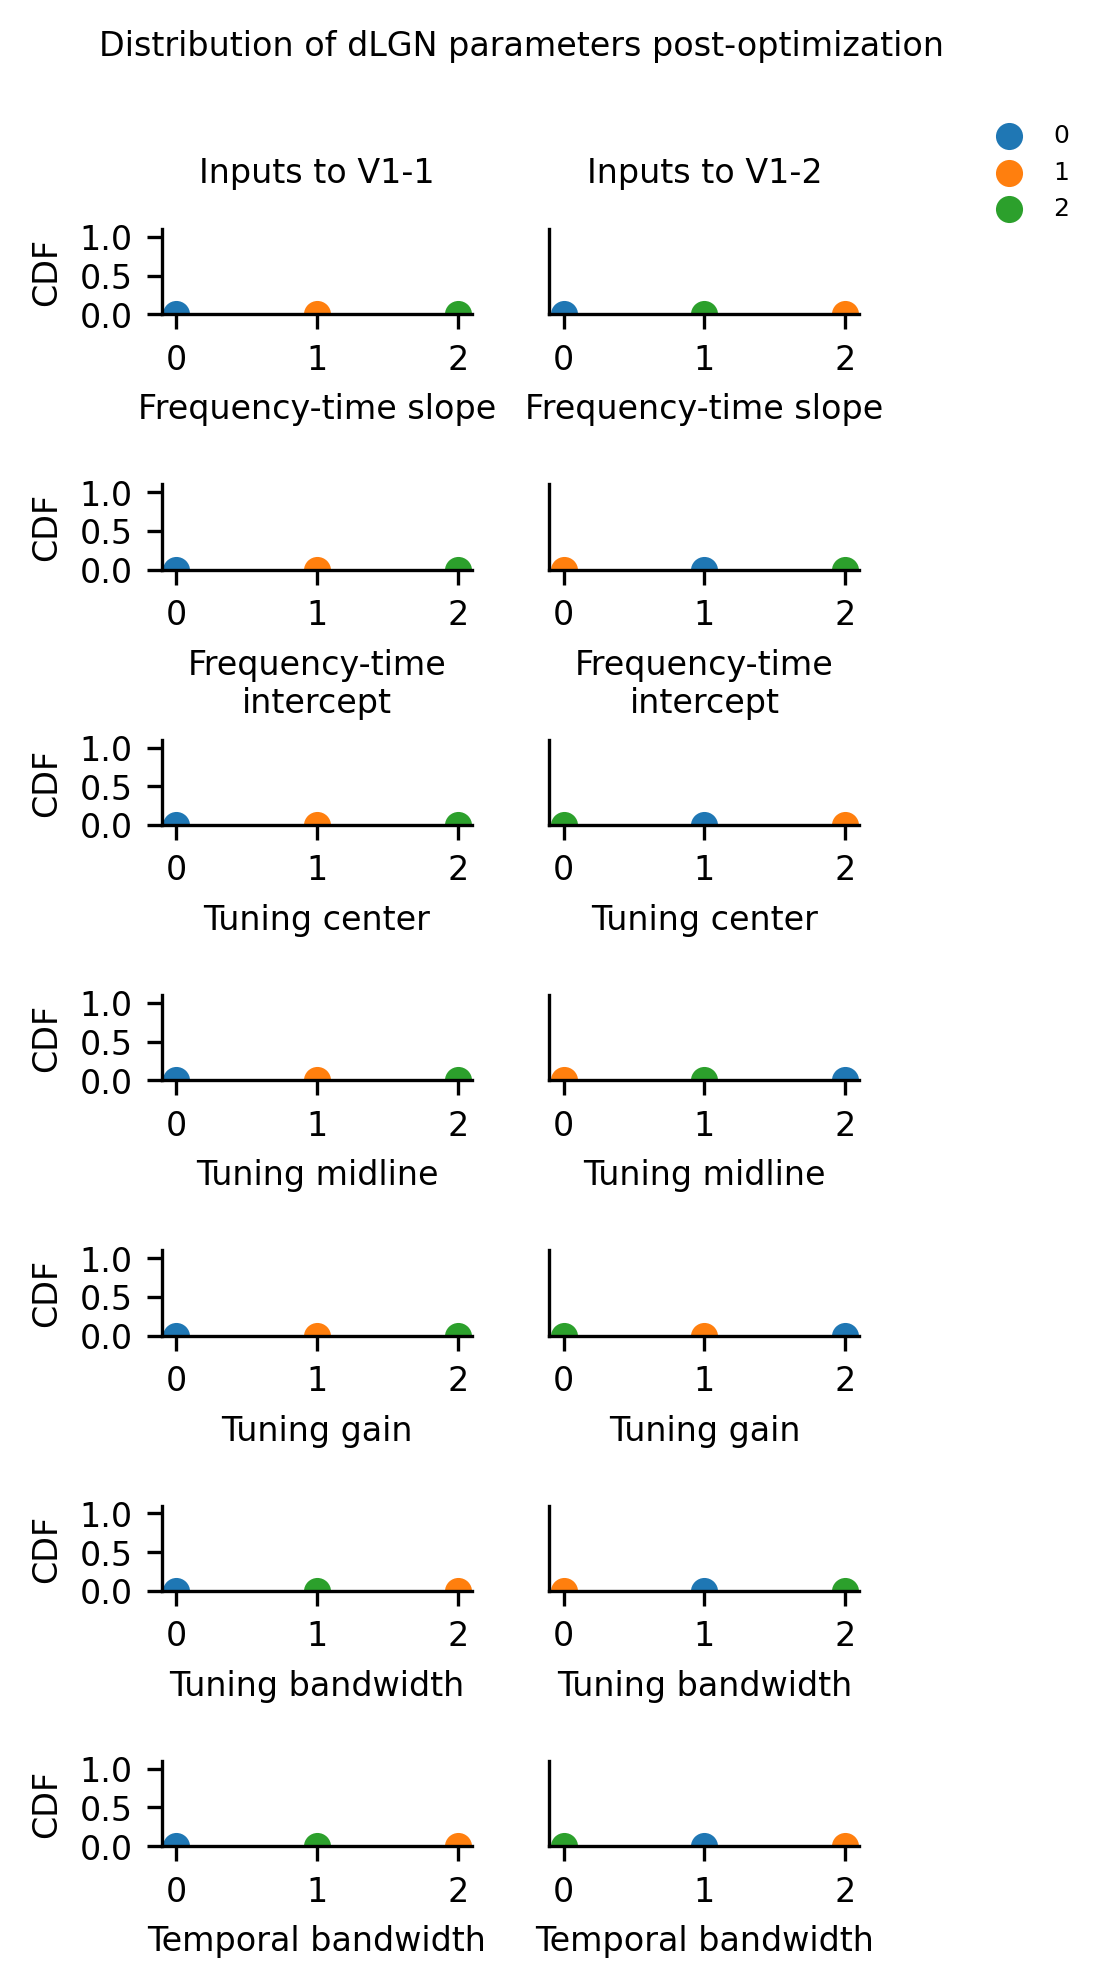

In [11]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(perm_combos[0, row, u, i], [0], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)


In [12]:
# Make the permutation matrices
perm_combos = np.array(list(combinations((combinations(permutations(np.arange(3)), 2)), 7)))#.transpose(0,2,3,1)

perm_combos = tf.one_hot(
    perm_combos,
    3,
    axis=-1,
)
perm_combos = tf.transpose(perm_combos, (0,1,2,4,3))

perm_combos = tf.where(perm_combos == 1.0, 
                  tf.ones_like(perm_combos) * 10.0,   # large positive
                  tf.ones_like(perm_combos) * -10.0)  # large negative

In [13]:
model2 = SGCCircuit(bounds = param_bounds, enforce_permutation=perm_combos[:10])
model2.load_saved_parameters(optimizer1.outputs['final_epoch_params'])

In [14]:
optimizer2 = Optimize(model2, epochs=100)
optimizer2.fit(X,Y_true)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x000002A4550729D0>
Training step = 0, N_exploration_samples = 10,
min_loss = 1.1740202903747559
med_loss = 6.563666820526123
max_loss = 25.005390167236328



<tf.Tensor: shape=(100, 10), dtype=float16, numpy=
array([[ 6.31  ,  2.453 ,  6.82  , 12.61  ,  1.174 ,  6.12  , 25.    ,
         5.223 ,  8.46  , 15.85  ],
       [ 6.29  ,  2.447 ,  6.793 , 12.58  ,  1.169 ,  6.098 , 24.94  ,
         5.203 ,  8.44  , 15.8   ],
       [ 6.273 ,  2.44  ,  6.766 , 12.54  ,  1.164 ,  6.08  , 24.88  ,
         5.184 ,  8.41  , 15.75  ],
       [ 6.258 ,  2.434 ,  6.742 , 12.51  ,  1.159 ,  6.055 , 24.83  ,
         5.168 ,  8.38  , 15.7   ],
       [ 6.242 ,  2.426 ,  6.715 , 12.47  ,  1.154 ,  6.035 , 24.77  ,
         5.15  ,  8.35  , 15.66  ],
       [ 6.227 ,  2.418 ,  6.688 , 12.44  ,  1.149 ,  6.01  , 24.7   ,
         5.133 ,  8.33  , 15.61  ],
       [ 6.207 ,  2.412 ,  6.664 , 12.4   ,  1.145 ,  5.992 , 24.64  ,
         5.117 ,  8.3   , 15.555 ],
       [ 6.19  ,  2.404 ,  6.637 , 12.37  ,  1.14  ,  5.97  , 24.58  ,
         5.098 ,  8.266 , 15.51  ],
       [ 6.176 ,  2.398 ,  6.613 , 12.33  ,  1.136 ,  5.95  , 24.52  ,
         5.082 ,  8.24

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

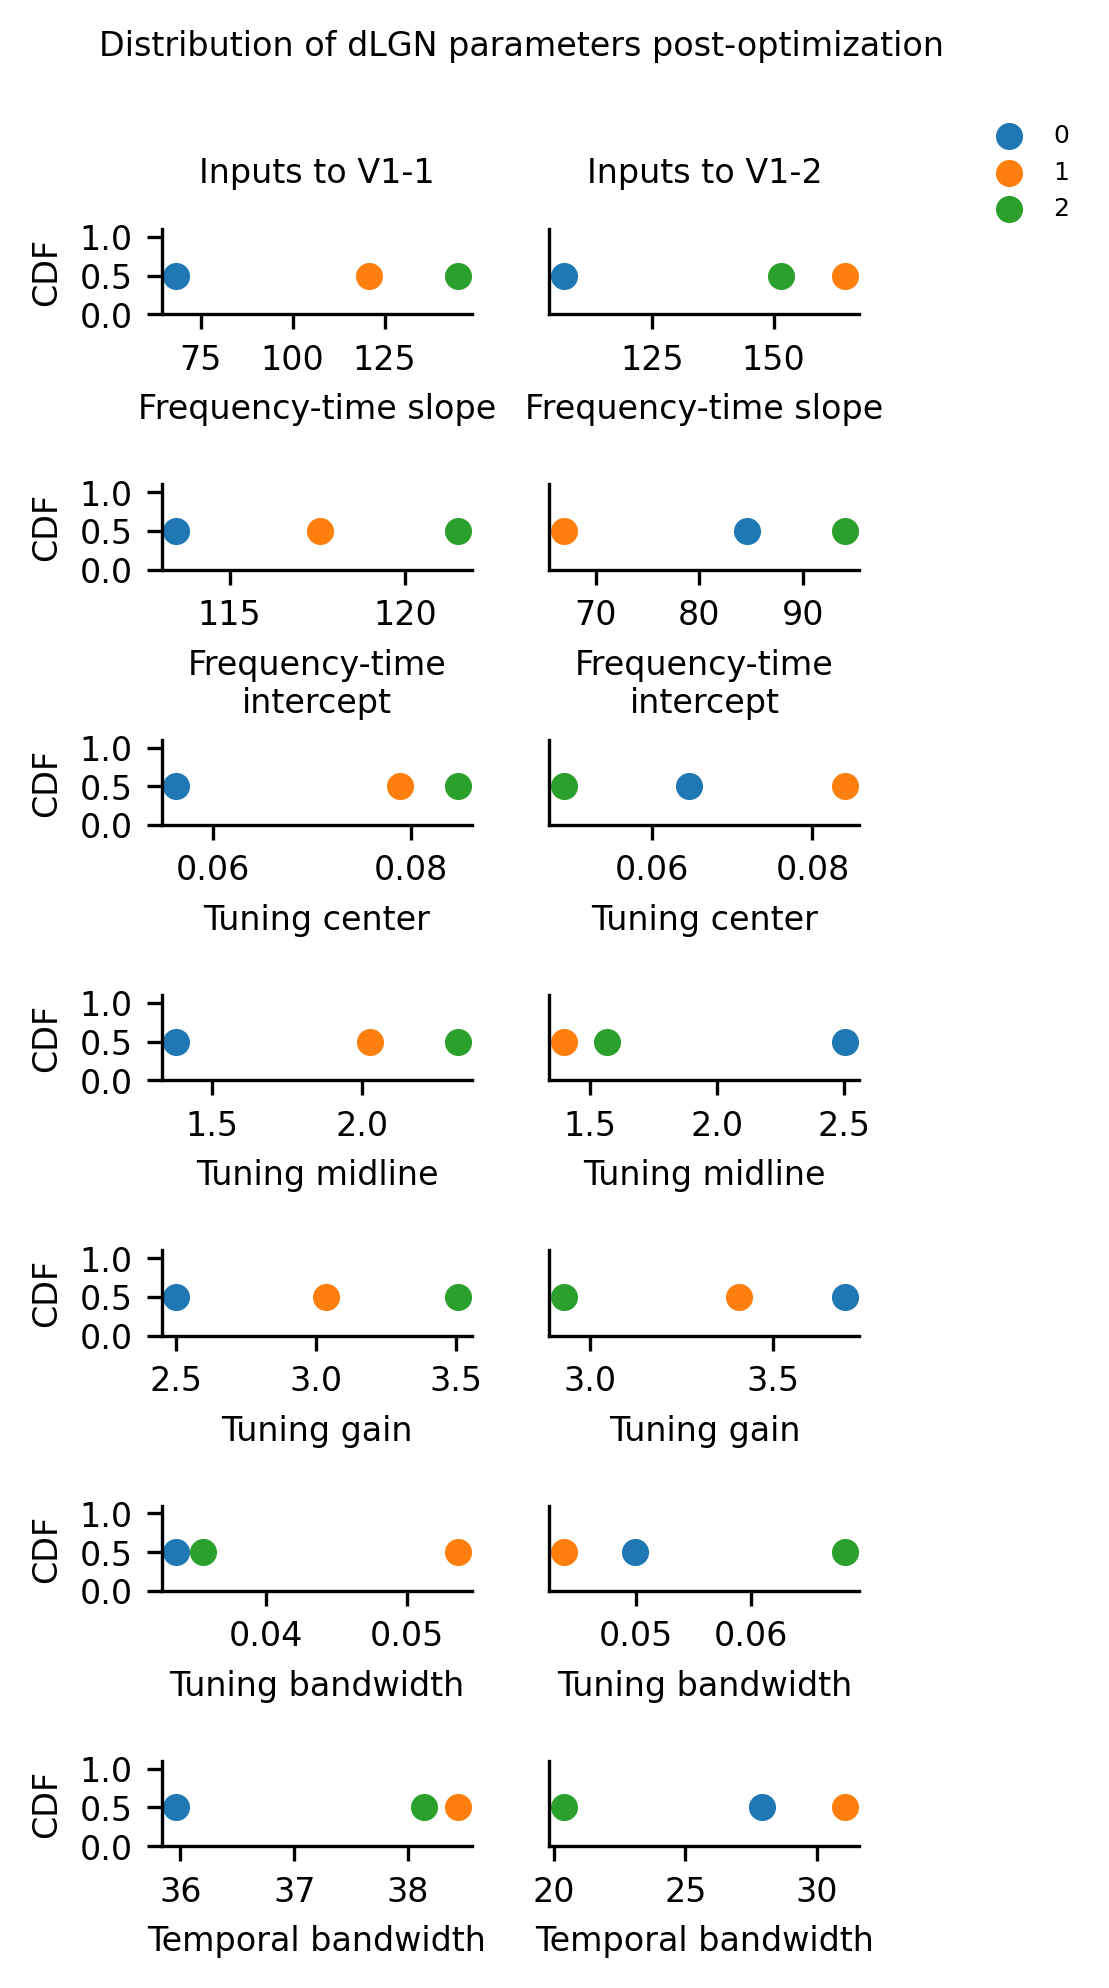

In [15]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(model2.params['dLGN_params'][0, u, i, row, 0, 0], [0.5], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)


In [16]:
perm_combos = np.array(list(combinations((combinations(permutations(np.arange(3)), 2)), 7)))

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

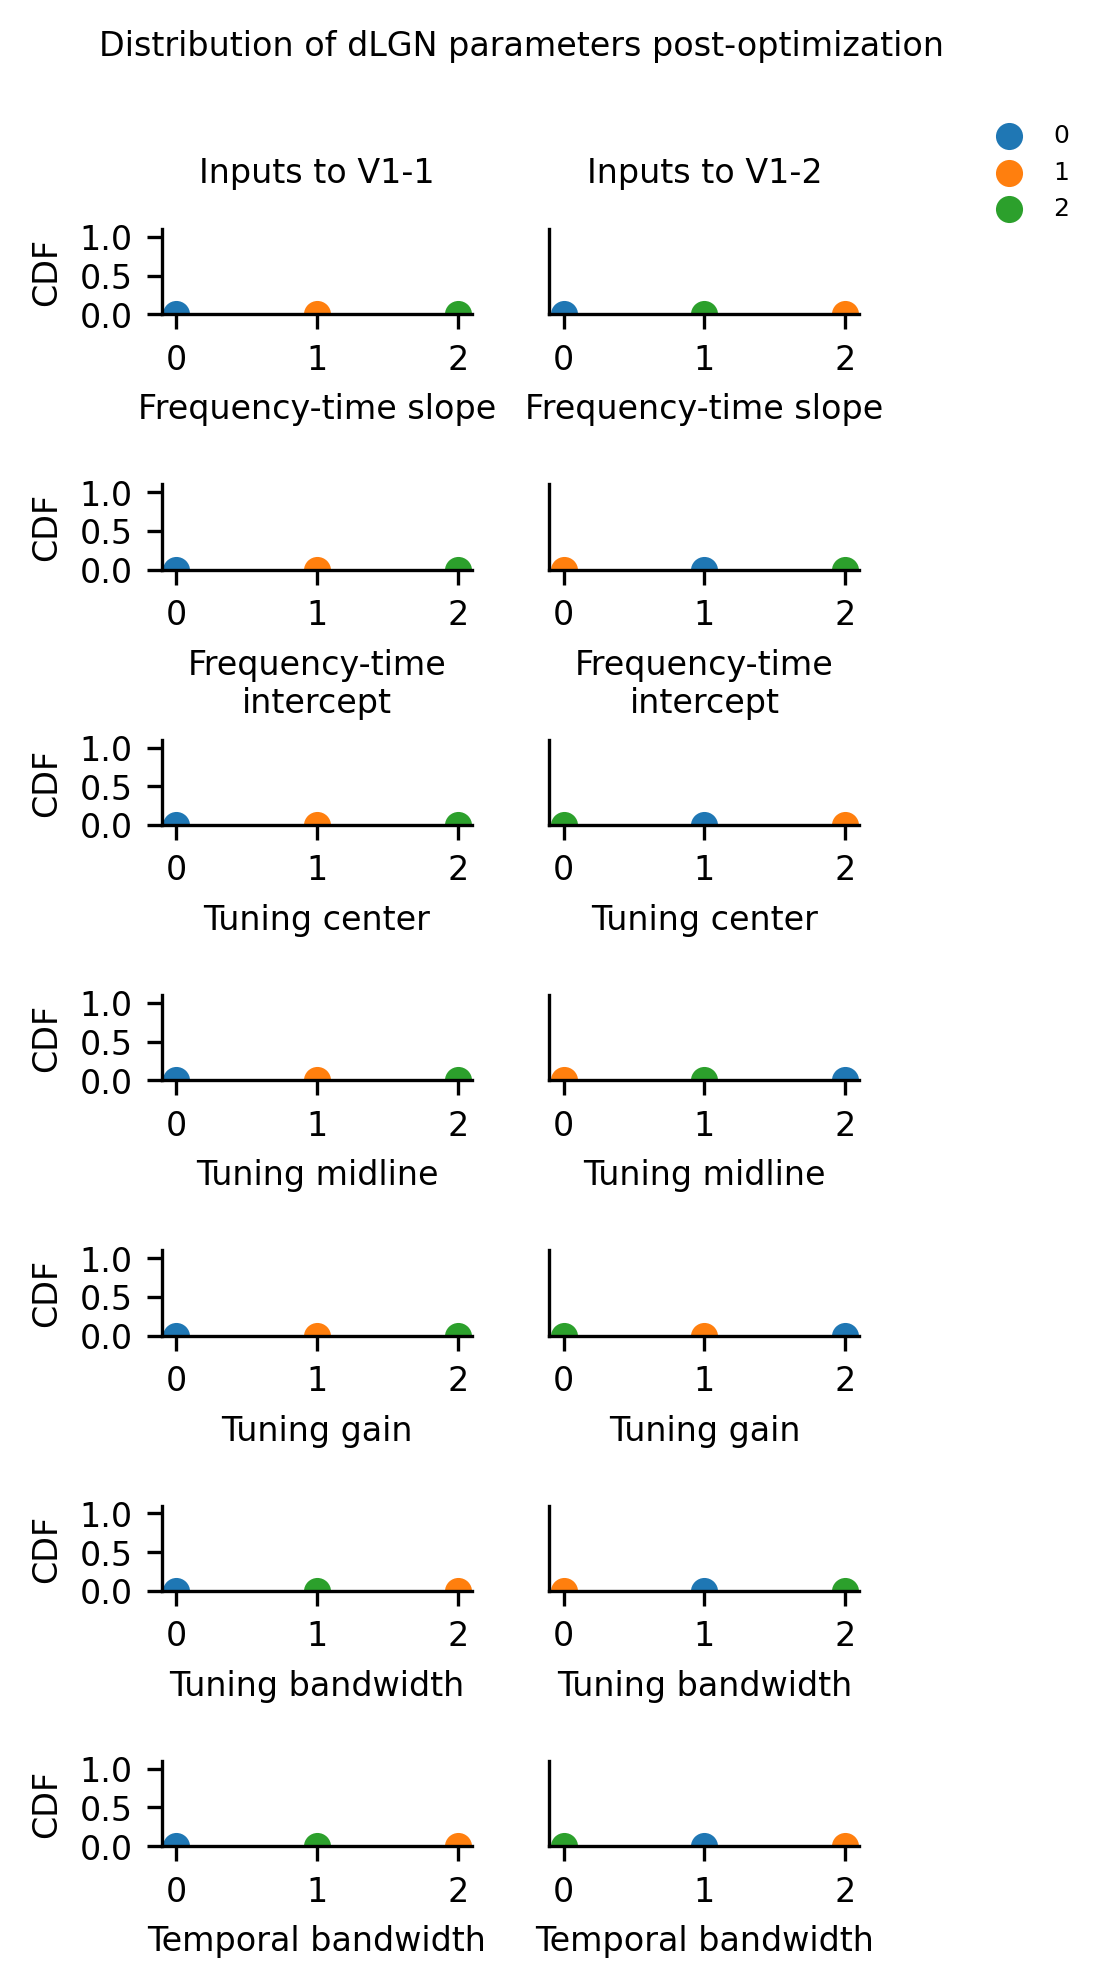

In [17]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(perm_combos[0, row, u, i], [0], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)
